# Model diagnostics for perpetual-funding signals

This analysis reads only current, complete canonical prediction catalog rows. A row retains its
training, prediction, fold, and checkpoint identity. IC, AUC, and loss diagnose models; they do
not select the trading configuration. Selection occurs after validation backtests and uses Sharpe.

**Learning objectives**

- audit the complete model and checkpoint population through the prediction catalog;
- compare diagnostic metrics without using them as the strategy selection rule; and
- interpret causal evidence separately from predictive performance.

**Book reference:** Chapters 11 to 19, model comparison and diagnostics.

**Prerequisites:** complete canonical outputs from the model execution notebooks and the causal
notebook.

In [1]:
import os

import plotly.express as px
import polars as pl
from IPython.display import Markdown

from case_studies.crypto_perps_funding.research_workflow import (
    OFFICIAL_POPULATION,
    open_study,
    plan_official_models,
)
from case_studies.research import CausalResult, OfficialPopulation
from utils.style import COLORS, ml4t_palette, show_plotly_with_alt

In [2]:
EXECUTION_TIER = "canonical"
WORKSPACE = os.environ.get("ML4T_OUTPUT_DIR", "")

## Complete predictive catalog

In [3]:
study = open_study(execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)
catalog = study.predictions.table(include_preview=EXECUTION_TIER == "preview").filter(
    (pl.col("identity_status") == "current")
    & (pl.col("execution_tier") == EXECUTION_TIER)
    & (pl.col("split") == "validation")
    & pl.col("complete")
)
if catalog.is_empty() or catalog["prediction_hash"].n_unique() != catalog.height:
    raise RuntimeError("the canonical model catalog is empty or has duplicate identities")

Canonical analysis also reconstructs the complete request population. Exact hash equality makes a
missing, extra, or differently resolved checkpoint a blocking error before diagnostics begin.

In [4]:
if EXECUTION_TIER == "canonical":
    population = OfficialPopulation.one(study, name=OFFICIAL_POPULATION)
    population.require_complete()
    declared_hashes = set(plan_official_models(study).expected_prediction_hashes)
    frozen_hashes = set(population.members)
    if frozen_hashes != declared_hashes:
        raise RuntimeError("the frozen model population differs from the declared requests")
    if set(catalog["prediction_hash"]) != frozen_hashes:
        raise RuntimeError("the canonical model catalog differs from the declared population")

In [5]:
catalog.select(
    "family",
    "label",
    "config_name",
    "checkpoint_kind",
    "checkpoint_value",
    "training_hash",
    "prediction_hash",
    "ic_mean",
    "auc_roc",
    "log_loss",
).sort("label", "family", "config_name", "checkpoint_value")

family,label,config_name,checkpoint_kind,checkpoint_value,training_hash,prediction_hash,ic_mean,auc_roc,log_loss
str,str,str,str,i64,str,str,f64,f64,f64
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",50,"""37de675e1842""","""0dad3e44cf8c""",0.02175,0.518891,0.700147
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",100,"""37de675e1842""","""fe76eeba2c05""",0.020056,0.515502,0.708815
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",150,"""37de675e1842""","""4092d4b0d2fb""",0.015598,0.514854,0.716435
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",200,"""37de675e1842""","""18a3050417a6""",0.016148,0.515254,0.724079
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",250,"""37de675e1842""","""4857b07cea83""",0.015166,0.515682,0.728557
…,…,…,…,…,…,…,…,…,…
"""tabular_dl""","""fwd_ret_8h""","""tabm_s""","""epoch""",100,"""b3a627bdc0b5""","""bdd596f5a37f""",-0.002668,null,null
"""tabular_dl""","""fwd_ret_8h""","""tabm_s""","""epoch""",125,"""b3a627bdc0b5""","""6f078b8199b3""",-0.002068,null,null
"""tabular_dl""","""fwd_ret_8h""","""tabm_s""","""epoch""",150,"""b3a627bdc0b5""","""55e22f9a8288""",-0.003744,null,null


## Diagnostic summaries

These tables describe the registered validation predictions without collapsing checkpoint
identity or intersecting away missing keys. Any incomplete row was rejected before this analysis.

In [6]:
diagnostics = catalog.select(
    "label",
    "family",
    "config_name",
    "checkpoint_kind",
    "checkpoint_value",
    "training_hash",
    "prediction_hash",
    "n_folds",
    "ic_mean",
    "ic_std",
    "auc_roc",
    "log_loss",
).sort("label", "family", "config_name", "checkpoint_value")
diagnostics

label,family,config_name,checkpoint_kind,checkpoint_value,training_hash,prediction_hash,n_folds,ic_mean,ic_std,auc_roc,log_loss
str,str,str,str,i64,str,str,f64,f64,f64,f64,f64
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",50,"""37de675e1842""","""0dad3e44cf8c""",2.0,0.02175,0.008365,0.518891,0.700147
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",100,"""37de675e1842""","""fe76eeba2c05""",2.0,0.020056,0.004146,0.515502,0.708815
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",150,"""37de675e1842""","""4092d4b0d2fb""",2.0,0.015598,0.00211,0.514854,0.716435
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",200,"""37de675e1842""","""18a3050417a6""",2.0,0.016148,0.00512,0.515254,0.724079
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",250,"""37de675e1842""","""4857b07cea83""",2.0,0.015166,0.002449,0.515682,0.728557
…,…,…,…,…,…,…,…,…,…,…,…
"""fwd_ret_8h""","""tabular_dl""","""tabm_s""","""epoch""",100,"""b3a627bdc0b5""","""bdd596f5a37f""",2.0,-0.002668,0.000023,null,null
"""fwd_ret_8h""","""tabular_dl""","""tabm_s""","""epoch""",125,"""b3a627bdc0b5""","""6f078b8199b3""",2.0,-0.002068,0.003432,null,null
"""fwd_ret_8h""","""tabular_dl""","""tabm_s""","""epoch""",150,"""b3a627bdc0b5""","""55e22f9a8288""",2.0,-0.003744,0.00188,null,null


The distribution below retains every checkpoint. A family with more configured checkpoints is
therefore shown with more points rather than receiving extra weight in a collapsed ranking.

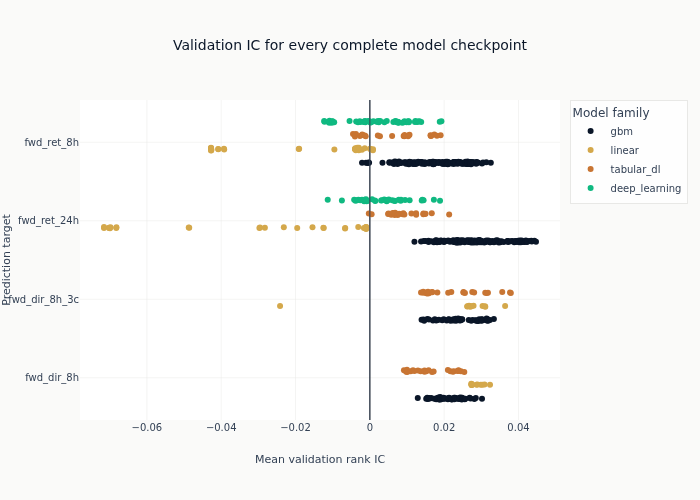

In [7]:
ic_points = catalog.filter(pl.col("ic_mean").is_not_null()).sort(
    "label", "family", "config_name", "checkpoint_value"
)
fig = px.strip(
    ic_points,
    x="ic_mean",
    y="label",
    color="family",
    hover_data=["config_name", "checkpoint_kind", "checkpoint_value"],
    title="Validation IC for every complete model checkpoint",
    labels={"ic_mean": "Mean validation rank IC", "label": "Prediction target"},
    color_discrete_sequence=ml4t_palette(5, categorical=True),
)
fig.add_vline(x=0, line_width=1, line_color=COLORS["neutral"])
fig.update_layout(legend_title_text="Model family")
show_plotly_with_alt(
    fig,
    "Horizontal strip plot with one point per complete model checkpoint, grouped by prediction "
    "target and colored by model family. A vertical zero line separates positive and negative "
    "validation rank correlations.",
)

## Separate causal result

The DML estimand is not placed in the predictive catalog. A reader-facing label selection must
resolve to exactly one current canonical causal identity.

In [8]:
causal = CausalResult.one(study, label="fwd_ret_8h", execution_tier=EXECUTION_TIER)
if not causal.complete:
    raise RuntimeError("causal result is incomplete")
causal_summary = pl.DataFrame(
    {
        "causal_hash": [causal.hash],
        "n_obs": [causal.metrics["n_obs"]],
        "effect": [causal.metrics["dml_effect"]],
        "hac_standard_error": [causal.metrics["dml_se_hac"]],
        "refutation_p": [causal.metrics["refutation_p"]],
    }
)
causal_summary

causal_hash,n_obs,effect,hac_standard_error,refutation_p
str,i64,f64,f64,f64
"""4a7d323f9c80""",54314,0.001032,0.000971,0.009901


In [9]:
# refutation_p is nullable by contract (utils/causal.py:1111), so it is reported as absent
# rather than formatted. A run whose refutation did not produce an empirical p-value is a
# weaker result, and saying so is more useful than omitting the sentence or failing to render.
_refutation = causal.metrics["refutation_p"]
_n_placebo = causal.spec["computation"]["refutation"]["n_placebo"]
_floor = 1.0 / (_n_placebo + 1)
if _refutation is None:
    _refutation_text = "No temporal refutation p-value was registered for this estimate."
elif _refutation <= _floor:
    # Reaching the floor is only possible when every placebo fit succeeded and none was
    # as extreme as the observed effect: p = (1 + exceedances) / (1 + successful), which
    # is at or below 1/(n+1) only when the numerator is 1 and the denominator is the full
    # requested count. So the requested count is the right denominator on this branch even
    # though `empirical_permutation_p` drops placebos whose second stage returned NaN.
    #
    # What the floor does NOT establish is that the underlying permutation tail probability
    # is at most 1/(n+1). That is a property of all permutations; this is a sample of n of
    # them, and zero exceedances in a sample bounds the sample, not the population.
    _refutation_text = (
        f"The temporal refutation p-value is **{_refutation:.3f}**, the smallest value "
        f"{_n_placebo} permutations can produce: every placebo fit succeeded and none was "
        f"as extreme as the observed effect. This is the Monte Carlo estimate sitting at "
        f"its resolution floor of 1/{_n_placebo + 1}, not a bound on the permutation tail "
        f"probability itself - resolving that finer needs more permutations, not a smaller "
        f"reported number."
    )
else:
    _refutation_text = (
        f"The temporal refutation p-value is **{_refutation:.3f}**, a Monte Carlo estimate "
        f"over {_n_placebo} requested permutations and no finer than that sample supports."
    )

_effect = causal.metrics["dml_effect"]
_se = causal.metrics["dml_se_hac"]
_t = _effect / _se if _se else float("nan")
# The block and the bandwidth are sized by different rules and the reader is being asked to
# weigh a ratio built from the second. `block_size` spans the treatment's construction window;
# the second-stage bandwidth is statsmodels' cube-root-of-decision-times default, raised only
# to cover the label horizon (utils/causal.py:467-472), which is one bar here. The realized
# bandwidth is not registered - `causal_runs` stores neither `hac_maxlags` nor `n_periods` -
# so the notebook states the rule rather than a number it cannot read back.
_block = causal.spec["computation"]["refutation"]["block_size"]
Markdown(
    f"The registered DML estimate is **{_effect:+.4g}** with "
    f"a HAC standard error of **{_se:.4g}**, a ratio of **{_t:.2f}**. {_refutation_text} "
    "Read the two together: the placebo test asks whether the estimation procedure "
    "manufactures this effect out of permuted treatment, and the standard error asks "
    "whether the effect is separable from zero at all. Surviving the first while failing "
    "the second is not evidence of a causal effect. "
    f"One caveat on the ratio: the placebo block spans **{_block}** bars of treatment "
    "persistence, but the standard error behind this ratio does not. Its HAC bandwidth is "
    "the cube-root-of-decision-times default raised to cover the label horizon, and nothing "
    "ties it to the treatment's window, so it covers materially fewer lags than the block. "
    "A bandwidth that under-covers serial dependence understates the standard error, so the "
    "ratio shown here is if anything generous - correcting it would widen the interval, not "
    "narrow it. "
    "This result describes the declared causal estimand and does not rank predictive models "
    "or trading strategies."
)

The registered DML estimate is **+0.001032** with a HAC standard error of **0.0009709**, a ratio of **1.06**. The temporal refutation p-value is **0.010**, the smallest value 100 permutations can produce: every placebo fit succeeded and none was as extreme as the observed effect. This is the Monte Carlo estimate sitting at its resolution floor of 1/101, not a bound on the permutation tail probability itself - resolving that finer needs more permutations, not a smaller reported number. Read the two together: the placebo test asks whether the estimation procedure manufactures this effect out of permuted treatment, and the standard error asks whether the effect is separable from zero at all. Surviving the first while failing the second is not evidence of a causal effect. One caveat on the ratio: the placebo block spans **42** bars of treatment persistence, but the standard error behind this ratio does not. Its HAC bandwidth is the cube-root-of-decision-times default raised to cover the label horizon, and nothing ties it to the treatment's window, so it covers materially fewer lags than the block. A bandwidth that under-covers serial dependence understates the standard error, so the ratio shown here is if anything generous - correcting it would widen the interval, not narrow it. This result describes the declared causal estimand and does not rank predictive models or trading strategies.

## Key takeaways and limitations

- Catalog completeness is checked against the declared canonical checkpoint population before any
  diagnostic is interpreted.
- IC, AUC, and loss describe predictions. Validation backtest Sharpe selects the trading
  configuration later in the pipeline.
- Model comparisons remain conditional on the finalized features, labels, universe, and validation
  period. The causal estimate also depends on its declared observed-confounder assumptions.